# 單頻道 Shorts 分析模板（template_single）

適用情境：類別只有 1 個頻道（如科普 PanSci）。
沒有跨頻道 ANOVA / dummy；改用『時間分段』+『Shorts vs 長片』檢定。

**改用：**修改下方參數 cell 的 `CSV_TIMESTAMP` / `CATEGORY_NAME` / `TARGET_CHANNELS`。

## 0. 參數

In [1]:
# === 參數區 ===========================================================
# 改類別只要改這三行；下方所有 cell 都引用這些變數
CSV_TIMESTAMP = "20260527-064747"      # PanSci 單頻道
TARGET_CHANNELS = None                  # None = 全部；單頻道無需過濾
CATEGORY_NAME = "科普"                   # 用於圖表標題、檔名
# ====================================================================

## 1. 匯入函式庫

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 中文字體（macOS 預設沒有 Microsoft 系列，使用 sans-serif 後備）
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang TC', 'Microsoft JhengHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

# 將 _templates/ 加入 sys.path 以便 import content_labeling
TPL_DIR = Path('../../analysis/_templates').resolve()
if str(TPL_DIR) not in sys.path:
    sys.path.insert(0, str(TPL_DIR))

print("✓ 函式庫載入完成")


✓ 函式庫載入完成


## 2. 載入 CSV

In [3]:
# 載入資料（路徑從 analysis/<cat>/ 回退兩層到 final project/）
df = pd.read_csv(f'../../data/processed/channel_videos_{CSV_TIMESTAMP}.csv', encoding='utf-8')
df_channels = pd.read_csv(f'../../data/processed/channels_{CSV_TIMESTAMP}.csv', encoding='utf-8')

if TARGET_CHANNELS is not None:
    df = df[df['channel_title'].isin(TARGET_CHANNELS)].copy()

print(f"✓ 資料載入：{len(df)} 列影片 / {len(df_channels)} 列頻道")
print(f"頻道：{df['channel_title'].unique().tolist()}")


✓ 資料載入：200 列影片 / 1 列頻道
頻道：['PanSci 泛科學']


## 3. 檢視資料結構

In [4]:
print(df.dtypes)
print()
print(df.head())
print()
print(df.describe())


video_id              str
title                 str
description           str
channel_id            str
channel_title         str
published_at          str
category_id         int64
tags                  str
default_language      str
duration_iso          str
duration_sec        int64
definition            str
caption              bool
view_count          int64
like_count          int64
comment_count       int64
favorite_count      int64
topic_categories      str
fetched_at            str
dtype: object

      video_id                                   title  \
0  6I7_4f6nmSo                        有洞！這顆尼安德塔人臼齒藏著秘密   
1  LAIbLFqKzyI  公布！美國地底的導電模型！電漿化的瞬間發生什麼事【泛科學NEWS EP60】   
2  EwMX9sxY1YU                          首次突破！量子世界超級擠壓術   
3  C_SlBl4Q0Vw                          什麼決定了植物細胞吃的元素？   
4  jHRmHtNj0l4                           確定了！腦的記憶架構這麼來   

                                         description  \
0  想和我們有更多互動嗎？加入會員 ► https://lihi1.com/BWeoe\n\n-...   
1  重溫泛科學YouTube會員專屬直播👉https://

## 4. 資料清理與前處理

In [5]:
# 資料清理 + 派生欄位
df_clean = df.copy()
df_clean['published_at'] = pd.to_datetime(df_clean['published_at'])
df_clean['fetched_at'] = pd.to_datetime(df_clean['fetched_at'])

# 標題長度（混合 CJK + 英文之視覺字符數）
df_clean['title_length'] = df_clean['title'].fillna('').apply(len)

# CJK / EN 分開計，跨類別比較時較公平
def count_cjk(s):
    return sum(1 for c in str(s) if '一' <= c <= '鿿')

def count_en_words(s):
    import re
    return len(re.findall(r'[A-Za-z]+', str(s)))

df_clean['title_length_cjk'] = df_clean['title'].fillna('').apply(count_cjk)
df_clean['title_length_en'] = df_clean['title'].fillna('').apply(count_en_words)

# tag_count: 用 flatten_video 的 '|' 串接，注意 NaN
df_clean['tag_count'] = df_clean['tags'].fillna('').apply(lambda s: 0 if not s else len(s.split('|')))

# Shorts 判定（沿用 Reg/02、Reg/03 的 180 秒閾值）
df_shorts = df_clean[df_clean['duration_sec'] <= 180].copy()

print(f"原始：{len(df_clean)}  Shorts (≤180s)：{len(df_shorts)}")
print(f"  每頻道 Shorts 篇數：")
print(df_shorts['channel_title'].value_counts())


原始：200  Shorts (≤180s)：154
  每頻道 Shorts 篇數：
channel_title
PanSci 泛科學    154
Name: count, dtype: int64


## 4.5 內容貼標（Layer 1-3）

In [6]:
# === §4.5 內容貼標（Layer 1-3） ============================
# 此 cell 由 content_labeling.py 注入
import content_labeling as cl

df_with_topics, topic_counts = cl.explode_topic_categories(df_shorts)
df_lab = cl.apply_keyword_labels(df_with_topics, text_cols=("title", "tags"))
buckets = cl.load_keyword_dict()
label_cols = [f"has_{b}" for b in buckets]

print("Layer 1 — topic 全體計數 (Top 15)：")
print(topic_counts.head(15))
print()

topic_dist = cl.topic_distribution_by_channel(df_with_topics)
print("Layer 1 — 頻道 × topic 比例：")
print(topic_dist)
print()

print("Layer 2 — 規則式關鍵字命中率（按頻道）：")
print(df_lab.groupby('channel_title')[label_cols].mean().round(3))
print()

try:
    tfidf = cl.tfidf_top_keywords_by_channel(df_lab, n=15)
    print("Layer 3 — TF-IDF Top 15 keywords / channel：")
    for ch, kws in tfidf.items():
        print(f"\n{ch}:")
        for kw, sc in kws:
            print(f"  {kw:20s}  {sc:.4f}")
except RuntimeError as e:
    print(f"Layer 3 跳過：{e}")


Building prefix dict from the default dictionary ...


Loading model from cache /var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/jieba.cache


Layer 1 — topic 全體計數 (Top 15)：
Health                   41
Society                  39
Lifestyle_(sociology)    19
Entertainment            14
Knowledge                11
Technology                2
Film                      2
Politics                  2
Food                      1
dtype: int64

Layer 1 — 頻道 × topic 比例：
            Lifestyle_(sociology)   Society    Health  Entertainment  \
PanSci 泛科學               0.123377  0.253247  0.266234       0.090909   

            Knowledge  Technology      Film  Politics      Food  
PanSci 泛科學   0.071429    0.012987  0.012987  0.012987  0.006494  

Layer 2 — 規則式關鍵字命中率（按頻道）：
               has_教學教育  has_挑戰對決  has_搞笑迷因  has_開箱評測  has_互動誘導  has_情緒詞  \
channel_title                                                              
PanSci 泛科學        0.013     0.013       0.0     0.006       0.0    0.026   

               has_品牌推廣  has_食物  has_運動  has_問句  
channel_title                                    
PanSci 泛科學        0.006   0.039   0.006   0.3

Loading model cost 0.207 seconds.


Prefix dict has been built successfully.


Layer 3 — TF-IDF Top 15 keywords / channel：

PanSci 泛科學:
  什麼                    0.3667
  科學家                   0.2445
  突破                    0.2139
  大腦                    0.1222
  秘密                    0.1222
  ai                    0.1222
  泛科學                   0.1222
  竟然                    0.0917
  一直                    0.0917
  決定                    0.0917
  量子                    0.0917
  容易                    0.0917
  自己                    0.0917
  直播                    0.0917
  這個                    0.0917


## 5. 描述性統計

In [7]:
# 描述性統計
metrics = ['view_count', 'like_count', 'comment_count', 'duration_sec',
           'title_length', 'tag_count']
print("Shorts 主要指標統計：")
for m in metrics:
    if m in df_shorts.columns:
        d = df_shorts[m].dropna()
        if len(d) == 0:
            continue
        print(f"  {m:15s} mean={d.mean():>12,.1f}  median={d.median():>10,.1f}  std={d.std():>12,.1f}")

# 頻道級摘要
print("\n每頻道摘要：")
agg = df_shorts.groupby('channel_title').agg(
    n_shorts=('video_id', 'count'),
    mean_view=('view_count', 'mean'),
    median_view=('view_count', 'median'),
    mean_like=('like_count', 'mean'),
    mean_comment=('comment_count', 'mean'),
)
print(agg)


Shorts 主要指標統計：
  view_count      mean=   184,526.7  median= 124,583.5  std=   193,290.1
  like_count      mean=     5,961.2  median=   4,130.5  std=     5,324.8
  comment_count   mean=       219.3  median=     164.5  std=       188.5
  duration_sec    mean=       155.6  median=     161.0  std=        29.6
  title_length    mean=        12.3  median=      11.0  std=         6.4
  tag_count       mean=         0.7  median=       1.0  std=         0.5

每頻道摘要：
               n_shorts      mean_view  median_view    mean_like  mean_comment
channel_title                                                                 
PanSci 泛科學          154  184526.727273     124583.5  5961.220779    219.285714


## 6. 發佈時間趨勢

In [8]:
# 發佈時間特徵
df_shorts['pub_date'] = df_shorts['published_at'].dt.date
df_shorts['pub_hour'] = df_shorts['published_at'].dt.hour
df_shorts['pub_day_of_week'] = df_shorts['published_at'].dt.day_name()
df_shorts['pub_hour_band'] = pd.cut(df_shorts['pub_hour'], bins=[-1,5,11,17,21,24],
                                     labels=['深夜','早','中','下','晚'])

# 按小時
print("按發佈時段平均觀看數：")
print(df_shorts.groupby('pub_hour_band', observed=False)['view_count'].mean().round(0))


按發佈時段平均觀看數：
pub_hour_band
深夜    223662.0
早     185463.0
中     172436.0
下          NaN
晚          NaN
Name: view_count, dtype: float64


## 6.1 時間分段 ANOVA（單頻道專用）

In [9]:
# 把 published_at 切成 3 段（早 / 中 / 近期），檢驗『不同時期發布的觀看數是否有差』
from scipy.stats import f_oneway

df_shorts_sorted = df_shorts.sort_values('published_at')
n = len(df_shorts_sorted)
if n >= 9:
    bins = pd.qcut(df_shorts_sorted['published_at'].astype('int64'),
                   q=3, labels=['早期','中期','近期'])
    df_shorts_sorted = df_shorts_sorted.assign(time_bucket=bins)
    grps = [g['view_count'].dropna().values for _, g in df_shorts_sorted.groupby('time_bucket', observed=False)]
    f, p = f_oneway(*grps)
    print(f"時間分段 ANOVA: F={f:.4f}  p={p:.4e}")
    print(df_shorts_sorted.groupby('time_bucket', observed=False)['view_count'].agg(['count','mean','median']))
else:
    print(f"樣本太少（n={n}），跳過時間分段 ANOVA")


時間分段 ANOVA: F=4.5054  p=1.2575e-02
             count           mean    median
time_bucket                                
早期              52  171105.250000  129527.5
中期              51  246298.529412  168528.0
近期              51  136439.568627   81623.0


## 6.2 發布時段 / 星期 / 標題長度 / 標籤數量 ANOVA（單頻道升級為主分析）

In [10]:
# 6.2 多面向 ANOVA：發布時段 / 星期 / 標題長度 qcut / 標籤數量
from scipy.stats import f_oneway

def run_anova(df, group_col, label):
    grps = [g['view_count'].dropna().values for _, g in df.groupby(group_col, observed=False) if len(g) >= 2]
    if len(grps) < 2:
        print(f"[{label}] 組數不足 (only {len(grps)})，跳過")
        return
    f, p = f_oneway(*grps)
    sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
    print(f"[{label}] F={f:.4f}  p={p:.4e} {sig}")
    print(df.groupby(group_col, observed=False)['view_count'].agg(['count', 'mean', 'median']).round(0))
    print()

# (1) 發布時段：早/中/下/晚/深夜
print('=== (1) 發布時段 ANOVA（PanSci 9 成集中在 19 點 Taiwan/11 UTC，組間極不平衡）===')
run_anova(df_shorts, 'pub_hour_band', 'pub_hour_band')

# (2) 星期
print('=== (2) 星期 ANOVA ===')
run_anova(df_shorts, 'pub_day_of_week', 'day_of_week')

# (3) 標題長度 qcut 三等分
df_shorts = df_shorts.copy()
try:
    df_shorts['title_len_q3'] = pd.qcut(df_shorts['title_length'], q=3, labels=['短','中','長'], duplicates='drop')
    print('=== (3) 標題長度 ANOVA (qcut q=3) ===')
    print('分位邊界：', pd.qcut(df_shorts['title_length'], q=3, duplicates='drop').cat.categories.tolist())
    run_anova(df_shorts, 'title_len_q3', 'title_len_q3')
except Exception as e:
    print(f'標題長度 qcut 失敗：{e}')

# (4) 標籤數量分組 (0 / 1 / >=2)
def bucket_tags(n):
    if n == 0: return '0'
    if n == 1: return '1'
    return '>=2'
df_shorts['tag_bucket'] = df_shorts['tag_count'].apply(bucket_tags)
print('=== (4) 標籤數量 ANOVA ===')
run_anova(df_shorts, 'tag_bucket', 'tag_bucket')


=== (1) 發布時段 ANOVA（PanSci 9 成集中在 19 點 Taiwan/11 UTC，組間極不平衡）===
[pub_hour_band] F=0.0571  p=8.1154e-01 ns
               count      mean    median
pub_hour_band                           
深夜                 1  223662.0  223662.0
早                139  185463.0  125496.0
中                 14  172436.0   95776.0
下                  0       NaN       NaN
晚                  0       NaN       NaN

=== (2) 星期 ANOVA ===
[day_of_week] F=0.3189  p=9.2629e-01 ns
                 count      mean    median
pub_day_of_week                           
Friday              15  146203.0  106264.0
Monday              13  195561.0  206321.0
Saturday            22  197810.0  103298.0
Sunday              25  162678.0  129994.0
Thursday            26  217389.0  128232.0
Tuesday             27  191253.0  146241.0
Wednesday           26  171040.0  118290.0

=== (3) 標題長度 ANOVA (qcut q=3) ===
分位邊界： [Interval(5.999, 10.0, closed='right'), Interval(10.0, 12.0, closed='right'), Interval(12.0, 67.0, closed='right')]
[t

## 7. 相關性分析

In [11]:
# 相關性分析
analysis_cols = ['view_count', 'like_count', 'comment_count', 'duration_sec',
                 'title_length', 'tag_count']
corr = df_shorts[analysis_cols].corr()
print("相關係數矩陣：")
print(corr.round(3))

print("\n與 view_count 的相關性顯著性檢定（Pearson）：")
for col in ['like_count', 'comment_count', 'duration_sec', 'title_length', 'tag_count']:
    d = df_shorts[[col, 'view_count']].dropna()
    if len(d) > 2:
        r, p = stats.pearsonr(d[col], d['view_count'])
        sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
        print(f"  {col:15s} r={r:+.4f}  p={p:.4e} {sig}")


相關係數矩陣：
               view_count  like_count  comment_count  duration_sec  \
view_count          1.000       0.957          0.732         0.045   
like_count          0.957       1.000          0.787         0.087   
comment_count       0.732       0.787          1.000         0.078   
duration_sec        0.045       0.087          0.078         1.000   
title_length       -0.033      -0.075         -0.041        -0.384   
tag_count          -0.068      -0.035         -0.023        -0.037   

               title_length  tag_count  
view_count           -0.033     -0.068  
like_count           -0.075     -0.035  
comment_count        -0.041     -0.023  
duration_sec         -0.384     -0.037  
title_length          1.000      0.118  
tag_count             0.118      1.000  

與 view_count 的相關性顯著性檢定（Pearson）：
  like_count      r=+0.9574  p=7.1455e-84 ***
  comment_count   r=+0.7320  p=4.0552e-27 ***
  duration_sec    r=+0.0447  p=5.8234e-01 ns
  title_length    r=-0.0331  p=6.8345e-01 n

## 7.5 內容標籤與觀看數的關係

In [12]:
# === §7.5 內容標籤與觀看數的關係 ==========================
# 此 cell 由 content_labeling.py 注入：卡方 + logistic
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

# 高觀看 = top quartile（每頻道內或整體）
view_q3 = df_lab['view_count'].quantile(0.75)
df_lab['top_quartile'] = (df_lab['view_count'] >= view_q3).astype(int)

print(f"top_quartile 門檻：view_count >= {view_q3:,.0f}")
print()

print("每個 label vs 高觀看 卡方檢定：")
for col in label_cols:
    if df_lab[col].sum() < 5 or df_lab[col].sum() > len(df_lab) - 5:
        print(f"  {col:25s} (樣本太集中, 跳過)")
        continue
    tab = pd.crosstab(df_lab[col], df_lab['top_quartile'])
    chi2, p, _, _ = chi2_contingency(tab)
    sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
    print(f"  {col:25s} chi2={chi2:6.2f}  p={p:.4e} {sig}")

# Logistic：P(top_quartile) ~ has_*
formula = "top_quartile ~ " + " + ".join(label_cols)
try:
    model = smf.logit(formula=formula, data=df_lab).fit(disp=False)
    print("\nLogistic 迴歸：")
    print(model.summary())
except Exception as e:
    print(f"\nLogistic 跳過：{e}")


top_quartile 門檻：view_count >= 228,596

每個 label vs 高觀看 卡方檢定：
  has_教學教育                  (樣本太集中, 跳過)
  has_挑戰對決                  (樣本太集中, 跳過)
  has_搞笑迷因                  (樣本太集中, 跳過)
  has_開箱評測                  (樣本太集中, 跳過)
  has_互動誘導                  (樣本太集中, 跳過)
  has_情緒詞                   (樣本太集中, 跳過)
  has_品牌推廣                  (樣本太集中, 跳過)
  has_食物                    chi2=  0.00  p=9.8512e-01 ns
  has_運動                    (樣本太集中, 跳過)
  has_問句                    chi2=  0.05  p=8.2510e-01 ns

Logistic 跳過：Singular matrix


## 8. Top 10 視覺化

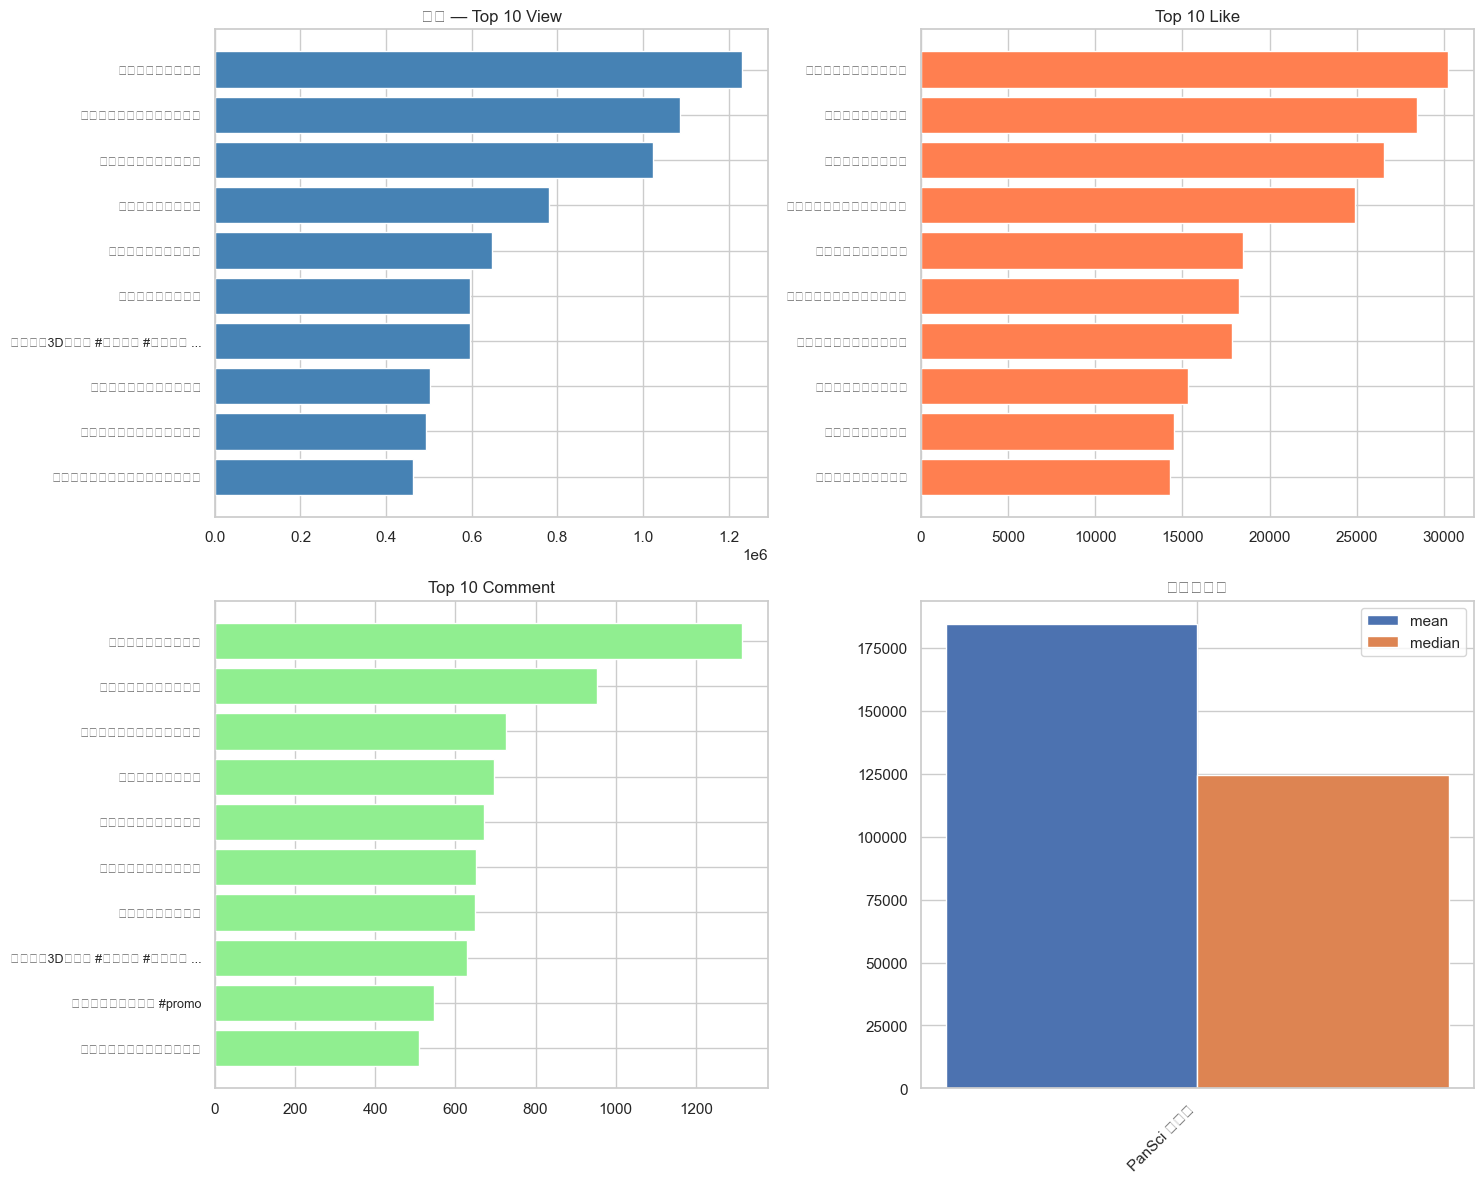

In [13]:
# Top 10 視覺化
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

t10v = df_shorts.nlargest(10, 'view_count')
axes[0,0].barh(range(len(t10v)), t10v['view_count'].values, color='steelblue')
axes[0,0].set_yticks(range(len(t10v)))
axes[0,0].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10v['title']], fontsize=9)
axes[0,0].set_title(f'{CATEGORY_NAME} — Top 10 View'); axes[0,0].invert_yaxis()

t10l = df_shorts.nlargest(10, 'like_count')
axes[0,1].barh(range(len(t10l)), t10l['like_count'].values, color='coral')
axes[0,1].set_yticks(range(len(t10l)))
axes[0,1].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10l['title']], fontsize=9)
axes[0,1].set_title('Top 10 Like'); axes[0,1].invert_yaxis()

t10c = df_shorts.nlargest(10, 'comment_count')
axes[1,0].barh(range(len(t10c)), t10c['comment_count'].values, color='lightgreen')
axes[1,0].set_yticks(range(len(t10c)))
axes[1,0].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10c['title']], fontsize=9)
axes[1,0].set_title('Top 10 Comment'); axes[1,0].invert_yaxis()

ch_summary = df_shorts.groupby('channel_title')['view_count'].agg(['mean','median']).reset_index()
x = range(len(ch_summary))
axes[1,1].bar([i-0.2 for i in x], ch_summary['mean'], 0.4, label='mean')
axes[1,1].bar([i+0.2 for i in x], ch_summary['median'], 0.4, label='median')
axes[1,1].set_xticks(list(x))
axes[1,1].set_xticklabels(ch_summary['channel_title'], rotation=45, ha='right')
axes[1,1].set_title('頻道觀看數'); axes[1,1].legend()

plt.tight_layout(); plt.show()


## 9. Shorts vs 長片 兩樣本檢定（取代頻道 ANOVA）

In [14]:
# 單頻道無法跨頻道 ANOVA；改用 Shorts vs 長片兩樣本檢定
from scipy.stats import mannwhitneyu

df_short = df_clean[df_clean['duration_sec'] <= 180]
df_long = df_clean[df_clean['duration_sec'] > 180]
print(f"Shorts n={len(df_short)}  長片 n={len(df_long)}")

if len(df_short) >= 5 and len(df_long) >= 5:
    for col in ['view_count', 'like_count', 'comment_count']:
        a = df_short[col].dropna()
        b = df_long[col].dropna()
        u, p = mannwhitneyu(a, b, alternative='two-sided')
        sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
        print(f"  {col:15s} Shorts mean={a.mean():>12,.0f}  Long mean={b.mean():>12,.0f}  p={p:.4e} {sig}")
else:
    print("樣本不足，跳過")


Shorts n=154  長片 n=46
  view_count      Shorts mean=     184,527  Long mean=     134,678  p=9.7684e-02 ns
  like_count      Shorts mean=       5,961  Long mean=       3,821  p=1.3168e-02 *
  comment_count   Shorts mean=         219  Long mean=         287  p=1.6925e-01 ns


## 10. OLS（只跑 model 1，無 channel dummy）

In [15]:
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_reg = df_shorts[['view_count', 'duration_sec', 'title_length', 'tag_count']].dropna()
print(f"迴歸樣本數：{len(df_reg)}")

if len(df_reg) >= 10:
    scaler = StandardScaler()
    feats = ['duration_sec', 'title_length', 'tag_count']
    dfs = df_reg.copy()
    dfs[feats] = scaler.fit_transform(df_reg[feats])

    m1 = smf.ols('view_count ~ duration_sec + title_length + tag_count', data=dfs).fit()
    print(m1.summary())
    print(f"\nR² = {m1.rsquared:.4f}  Adj R² = {m1.rsquared_adj:.4f}")

    # VIF
    X = m1.model.exog
    names = m1.model.exog_names
    vif = pd.DataFrame({"Variable": names[1:],
                        "VIF": [variance_inflation_factor(X, i) for i in range(1, X.shape[1])]})
    print("\nVIF：")
    print(vif.to_string(index=False))
else:
    print("樣本太少，跳過迴歸")


迴歸樣本數：154


                            OLS Regression Results                            
Dep. Variable:             view_count   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.013
Method:                 Least Squares   F-statistic:                    0.3240
Date:                Wed, 27 May 2026   Prob (F-statistic):              0.808
Time:                        14:57:14   Log-Likelihood:                -2092.0
No. Observations:                 154   AIC:                             4192.
Df Residuals:                     150   BIC:                             4204.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1.845e+05   1.57e+04     11.768   

## 11. 結論

（依分析結果手動撰寫）